# Synthetic Experiments
**Benchmarking teleconnection methods on toy models: weight-pattern recovery and Granger causality testing.**

This notebook is a self-contained, publication-ready pipeline:
1. Imports
2. Configuration (toy-model parameters & grid-search settings)
3. Experiment 1 — Single-run: weight pattern recovery + p-values
4. Experiment 2 — Grid search over N and m (Type I error & Power)
5. Showing / saving results
6. Final composite figures ready for publication

## 1 — Imports

In [1]:
# Standard library
import os
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append("../")

# Data
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Visualisation
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Progress
from tqdm import tqdm

# Local package — GPCA + teleconnection baselines
from models.granger_pca import GrangerPCA
from models.teleconnection_models import (
    RegressionAnalysis, CompositeAnalysis,
    CanonicalCorrelationAnalysis, SpatialAveraging, PrincipalComponents,
)
from src.granger_causality_test import test_granger_causality_mbb, test_granger_causality
from src.functions_synthetic_experiements import run_experiment, generate_m_values

np.random.seed(2025)

## 2 — Configuration
All experiment parameters are centralised here.

In [2]:
# ── Output directories ────────────────────────────────────────────────────────
FIG_DIR       = "../figures/synthetic"
GRID_FIG_DIR  = "../figures/synthetic/grid_experiments"

# ── Experiment 1 : single-run toy model ──────────────────────────────────────
EXP1 = dict(
    N             = 2000,   # time-series length
    m             = 5,      # latent dimension (must be divisible by 5)
    d             = 20,     # observed Y dimension
    u             = 0.2,   # causal link strength X → Y
    train_ratio   = 0.80,
    lag           = 3,      # lag used for GPCA fitting
    lag_range     = range(1, 5),
    lag_criterion = "BIC",
)

# ── Experiment 2 : grid search (N × m) ───────────────────────────────────────
EXP2 = dict(
    alpha     = 0.05,              # significance level
    B         = 20,                # Monte Carlo repetitions per (N, m) cell
    n_grid    = 10,                # grid resolution along each axis
    N_min     = 100,
    N_max     = 2000,
    m_min     = 5,
    m_max     = 1500,
    d         = 20,                # observed Y dimension (fixed)
    u_values  = [0.1, 0.2, 0.4],             # causal strengths to evaluate for power
)

# ── Publication figure style ──────────────────────────────────────────────────
PUB_RC = {
    "font.family":     "serif",
    "font.serif":      ["DejaVu Serif"],
    "font.size":       11,
    "axes.labelsize":  12,
    "axes.titlesize":  12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth":  1.2,
    "lines.linewidth": 1.8,
    "pdf.fonttype":    42,
    "ps.fonttype":     42,
}

# Derived grid values (computed once)
N_VALUES = np.unique(
    np.logspace(np.log10(EXP2["N_min"]), np.log10(EXP2["N_max"]),
                EXP2["n_grid"]).astype(int)
)
M_VALUES = generate_m_values(
    n_points=EXP2["n_grid"], m_min=EXP2["m_min"], m_max=EXP2["m_max"]
)

os.makedirs(FIG_DIR,      exist_ok=True)
os.makedirs(GRID_FIG_DIR, exist_ok=True)

## 3 — Experiment 1: Single-Run Toy Model
### 3.1 Data generation

In [3]:
assert EXP1["m"] % 5 == 0, "m must be divisible by 5 (one block per latent component A–E)"

N, m, d, u = EXP1["N"], EXP1["m"], EXP1["d"], EXP1["u"]
t = np.arange(1, N + 1)

# ── Driving processes ─────────────────────────────────────────────────────────
X  = np.random.normal(0, 1, (N, 1)) + np.sin(0.2 * t)[:, None] + np.cos(0.1 * t)[:, None]
Z1 = np.random.normal(0, 1, (N, 1)) + np.cos(0.4 * t)[:, None]
Z2 = np.random.normal(0, 1, (N, 1)) + np.cos(0.05 * t)[:, None]

# ── Block indices (5 latent components) ──────────────────────────────────────
block = m // 5
slices = {
    "A": slice(0,         block),
    "B": slice(block,     2 * block),
    "C": slice(2 * block, 3 * block),
    "D": slice(3 * block, 4 * block),
    "E": slice(4 * block, 5 * block),
}
A, B, C, D, E = slices["A"], slices["B"], slices["C"], slices["D"], slices["E"]

# ── Latent dynamics ───────────────────────────────────────────────────────────
# Block A: driven by X (causal link u) and Z1
# Block B: driven by Z1 only
# Block C: driven by Z1 and block A
# Block D: driven by Z2 and block C
# Block E: driven by Z1 and Z2 only
W = np.random.randn(N, m)
for i in range(3, N):
    W[i, A] += (0.2 * W[i-2, A] + u * 0.4 * X[i-1, 0] + u * 0.3 * X[i-2, 0]
                + u * 0.2 * X[i-3, 0] + 0.2 * Z1[i-1, 0] + 0.2 * Z1[i-2, 0])
    W[i, B] += 0.4 * W[i-1, B] + 0.5 * Z1[i-1, 0]
    W[i, C] += 0.1 * W[i-2, C] + 0.8 * Z1[i-2, 0] + 0.8 * W[i-1, A] + 0.4 * W[i-2, A]
    W[i, D] += 0.1 * W[i-2, D] - 0.7 * Z2[i-3, 0] + 0.8 * W[i-2, C]
    W[i, E] += 0.1 * W[i-1, E] + 0.8 * Z1[i-2, 0] + 0.6 * Z2[i-1, 0] + 0.2 * Z2[i-2, 0]

Y = W

# ── Train / test split ────────────────────────────────────────────────────────
train_size = int(N * EXP1["train_ratio"])
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

print(f"Train: {train_size}  |  Test: {N - train_size}  |  Y shape: {Y.shape}")

Train: 1600  |  Test: 400  |  Y shape: (2000, 5)


### 3.2 Model fitting

In [4]:
# ── GPCA ──────────────────────────────────────────────────────────────────────
gpca = GrangerPCA(
    maxlag=EXP1["lag"],
    maxlags=EXP1["lag_range"],
    method="diff_ratio",
    lag_criterion=EXP1["lag_criterion"],
)
gpca.fit(X_train, Y_train, Z=None, plot_lag_analysis=True, verbose=True)

# ── Baselines (same lag as selected by GPCA) ──────────────────────────────────
ca  = CompositeAnalysis(maxlag=gpca.maxlag)
ra  = RegressionAnalysis(maxlag=gpca.maxlag)
cca = CanonicalCorrelationAnalysis(maxlag=gpca.maxlag, n_components=1)
sa  = SpatialAveraging()
pc  = PrincipalComponents()

ca.fit(X_train, Y_train)
ra.fit(X_train, Y_train)
cca.fit(X_train, Y_train)
sa.fit(X_train, Y_train)
pc.fit(X_train, Y_train)

print(f"\nSelected lag: {gpca.maxlag}")

       eigs
0  0.035710
1  0.002061
2  0.001278

Selected lag: 3


### 3.3 Granger causality tests

In [5]:
lag = gpca.maxlag

cp_gpca = gpca.transform(Y_test)
cp_ca   = ca.transform(Y_test, type="PosNeg")
cp_ra   = ra.transform(Y_test)
cp_cca  = cca.transform(Y_test)
cp_sa   = sa.transform(Y_test)
cp_pc   = pc.transform(Y_test)

results_gpca = test_granger_causality(X_test[:, None], cp_gpca[:, 0], maxlag=[lag])
results_ra   = test_granger_causality(X_test[:, None], cp_ra,         maxlag=[lag])
results_ca   = test_granger_causality(X_test[:, None], cp_ca,         maxlag=[lag])
results_cca  = test_granger_causality(X_test[:, None], cp_cca,        maxlag=[lag])
results_sa   = test_granger_causality(X_test[:, None], cp_sa,         maxlag=[lag])
results_pc   = test_granger_causality(X_test[:, None], cp_pc,         maxlag=[lag])

gc_table = pd.concat(
    [
        results_gpca[results_gpca["lag"] == lag],
        results_cca[results_cca["lag"]   == lag],
        results_ca[results_ca["lag"]     == lag],
        results_ra[results_ra["lag"]     == lag],
        results_sa[results_sa["lag"]     == lag],
        results_pc[results_pc["lag"]     == lag],
    ],
    keys=["GPCA", "CCA", "Composites", "Regression", "Spatial Average", "PCA"],
).reset_index(level=0).rename(columns={"level_0": "Method"})

display(gc_table[["Method", "F_statistic", "p_value"]]
        .style.format({"F_statistic": "{:.3f}", "p_value": "{:.3e}"}))

,Method,F_statistic,p_value
0,GPCA,3.227,2.256e-02
0,CCA,3.746,1.123e-02
0,Composites,2.164,9.174e-02
0,Regression,1.982,1.161e-01
0,Spatial Average,1.354,2.566e-01
0,PCA,1.442,2.301e-01


## 4 — Experiment 2: Grid Search over N and m
### 4.1 Type I error (u = 0)

In [ ]:
alpha = EXP2["alpha"]
B     = EXP2["B"]
d     = EXP2["d"]

results_null = []
print("Running Type I error experiments (u = 0)...")
for _ in tqdm(range(B)):
    for N in N_VALUES:
        for m in M_VALUES:
            results_df, _ = run_experiment(N=N, m=m, d=d, u=0)
            for _, row in results_df.iterrows():
                results_null.append({
                    "N": N, "m": m,
                    "Method":   row["Method"],
                    "reject":   row["p_value"] <= alpha,
                    "p_value":  row["p_value"],
                    "snr":      row["snr"],
                })

rejection_null = (
    pd.DataFrame(results_null)
    .groupby(["N", "m", "Method"])["reject"]
    .mean().reset_index().rename(columns={"reject": "rejection_rate"})
)
rejection_null.to_csv(f"{GRID_FIG_DIR}/rejection_rates_null.csv", index=False)
print(f"Type I error results saved → {GRID_FIG_DIR}/rejection_rates_null.csv")

Running Type I error experiments (u = 0)...


  5%|▌         | 1/20 [02:53<54:47, 173.03s/it]

### 4.2 Power (u > 0)

In [ ]:
all_power_results = []
for u_val in EXP2["u_values"]:
    results_power = []
    print(f"Running power experiments (u = {u_val})...")
    for _ in tqdm(range(B)):
        for N in N_VALUES:
            for m in M_VALUES:
            
                results_df, _ = run_experiment(N=N, m=m, d=d, u=u_val)
                for _, row in results_df.iterrows():
                    results_power.append({
                        "u":       u_val,
                        "N":       N,
                        "m":       m,
                        "Method":  row["Method"],
                        "reject":  row["p_value"] <= alpha,
                        "p_value": row["p_value"],
                        "snr":     row["snr"],
                    })

    rejection_power_u = (
        pd.DataFrame(results_power)
        .groupby(["u", "N", "m", "Method"])["reject"]
        .mean().reset_index().rename(columns={"reject": "rejection_rate"})
    )
    csv_name = f"rejection_rates_power_u_{str(u_val).replace('.', 'p')}.csv"
    rejection_power_u.to_csv(f"{GRID_FIG_DIR}/{csv_name}", index=False)
    print(f"  Power results saved → {GRID_FIG_DIR}/{csv_name}")

    all_power_results.append(rejection_power_u)

rejection_power_all = pd.concat(all_power_results, ignore_index=True)

Running power experiments (u = 0.2)...


100%|██████████| 10/10 [24:26<00:00, 146.69s/it]

  Power results saved → ../figures/grid_experiments/rejection_rates_power_u_0p2.csv


In [ ]:
rejection_power_all

,u,N,m,Method,rejection_rate
0,0.2,100,5,CCA,0.0
1,0.2,100,5,Composites,0.0
2,0.2,100,5,GPCA,0.0
3,0.2,100,5,PCA,0.0
4,0.2,100,5,Regression,0.0
...,...,...,...,...,...
595,0.2,1000,1000,Composites,0.3
596,0.2,1000,1000,GPCA,1.0
597,0.2,1000,1000,PCA,0.1
598,0.2,1000,1000,Regression,0.3


## 5 — Showing / Saving Results
### 5.1 Weight pattern heatmap (Experiment 1)

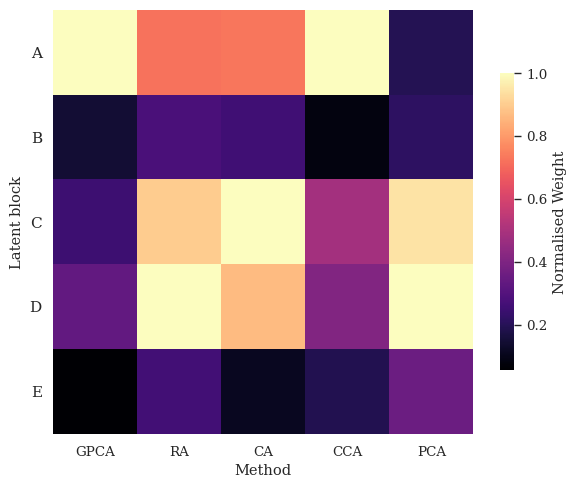

Weight heatmap saved → ../figures/weights_toy_model.pdf


In [ ]:
# Normalise weights to [0, 1] for each method
def _norm(w):
    w = np.abs(np.asarray(w)).ravel()
    return w / w.max()

weights_gpca = _norm(gpca.vects_[:, 0])
weights_ra   = _norm(ra.lr.coef_)
weights_ca   = _norm(ca.composites["PosNeg"].to_numpy())
weights_cca  = _norm(cca.cca.y_loadings_[:, 0])
weights_pc   = _norm(pc.pca.components_[0, :])

df_weights = pd.DataFrame(
    np.column_stack([weights_gpca, weights_ra, weights_ca, weights_cca, weights_pc]),
    columns=["GPCA", "RA", "CA", "CCA", "PCA"],
)

with mpl.rc_context(PUB_RC):
    sns.set_theme(context="paper", style="white", font="serif", font_scale=1.1)
    fig, ax = plt.subplots(figsize=(6, 5))

    sns.heatmap(
        df_weights, ax=ax, cmap="magma",
        cbar_kws={"shrink": 0.7, "label": "Normalised Weight"},
        linewidths=0.0, yticklabels=False,
    )

    block_size = len(df_weights) / 5
    ax.set_yticks([block_size * (i + 0.5) for i in range(5)])
    ax.set_yticklabels(["A", "B", "C", "D", "E"], rotation=0, fontsize=11)
    ax.set_xlabel("Method")
    ax.set_ylabel("Latent block")

    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/weights_toy_model.pdf", bbox_inches="tight")
    plt.savefig(f"{FIG_DIR}/weights_toy_model.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.show()
    print(f"Weight heatmap saved → {FIG_DIR}/weights_toy_model.pdf")

### 5.2 Rejection-rate heatmaps (Experiment 2)

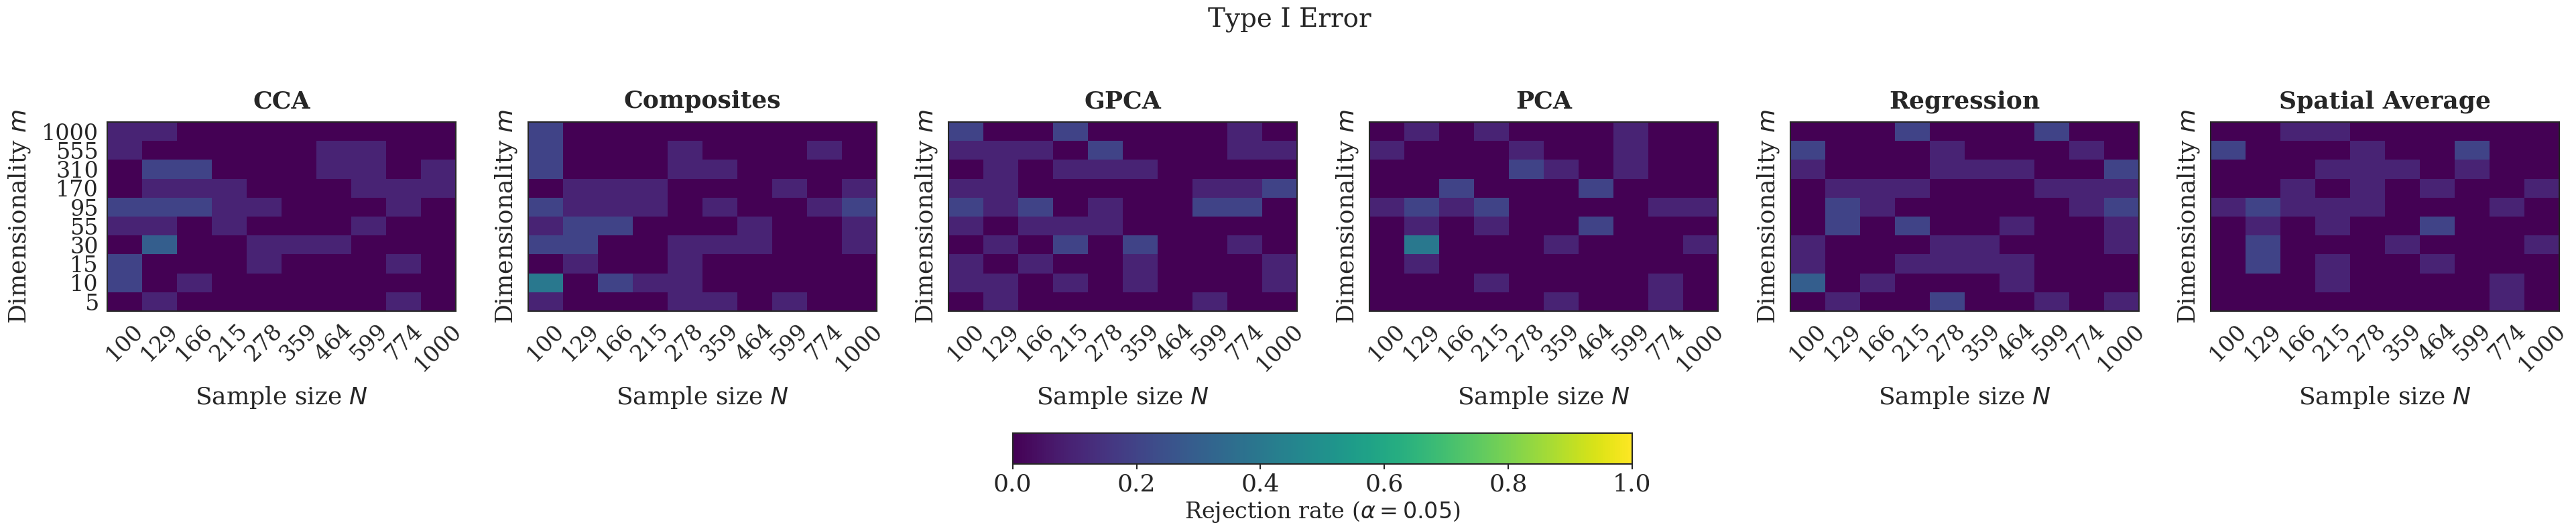

  Saved → ../figures/grid_experiments/rejection_heatmaps_null.pdf


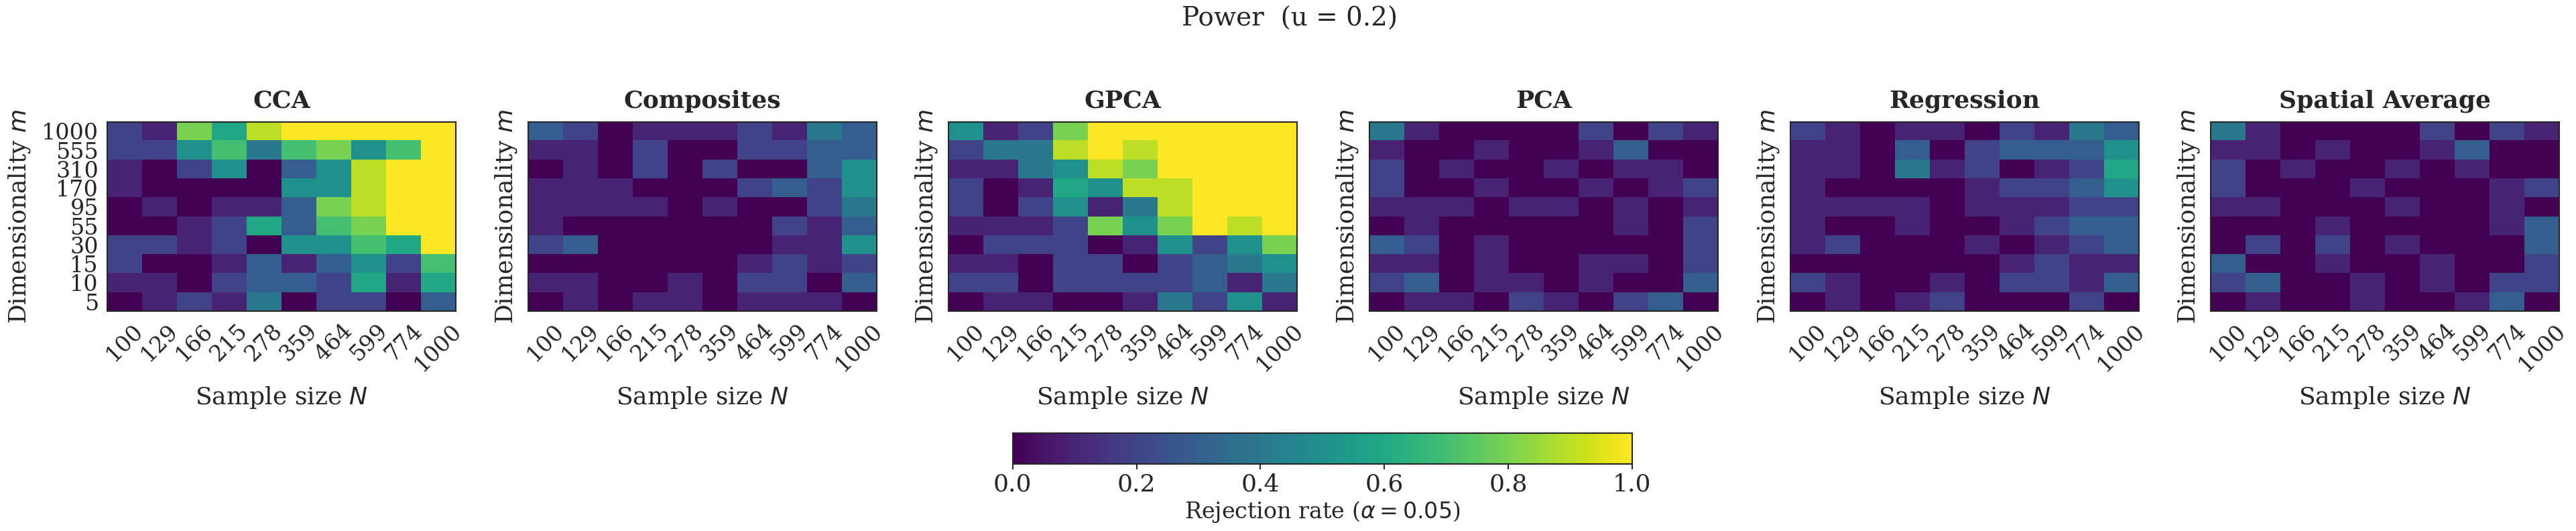

  Saved → ../figures/grid_experiments/rejection_heatmaps_power_u_0p2.pdf


In [ ]:
def plot_rejection_heatmaps(rejection_df, alpha, title, save_path):
    """Plot per-method rejection-rate heatmaps over the (N, m) grid."""
    heatmap_rc = {
        "text.usetex":     False,
        "font.family":     "serif",
        "font.size":       24,
        "axes.titlesize":  26,
        "axes.labelsize":  26,
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
        "axes.linewidth":  1.5,
    }

    methods = sorted(rejection_df["Method"].unique())
    with mpl.rc_context(heatmap_rc):
        fig, axes = plt.subplots(
            1, len(methods),
            figsize=(6.5 * len(methods), 7.5),
            sharex=True, sharey=True,
        )
        if len(methods) == 1:
            axes = [axes]

        cmap = plt.get_cmap("viridis")
        im   = None

        for ax, method in zip(axes, methods):
            df_m = rejection_df[rejection_df["Method"] == method]
            pivot = df_m.pivot(index="m", columns="N", values="rejection_rate").sort_index()

            im = ax.imshow(
                pivot.values, origin="lower", aspect="auto",
                cmap=cmap, vmin=0, vmax=1,
            )
            ax.set_xticks(np.arange(len(pivot.columns)))
            ax.set_xticklabels(pivot.columns, rotation=45)
            ax.set_yticks(np.arange(len(pivot.index)))
            ax.set_yticklabels(pivot.index)
            ax.set_title(method, pad=15, fontweight="bold")
            ax.set_xlabel(r"Sample size $N$", labelpad=10)
            ax.set_ylabel(r"Dimensionality $m$", labelpad=10)
            ax.tick_params(axis="both", which="major", width=1.5, length=6)

        cbar = fig.colorbar(im, ax=axes, orientation="horizontal",
                            fraction=0.08, pad=-0.3)
        cbar.set_label(rf"Rejection rate ($\alpha = {alpha}$)", fontsize=24)
        cbar.ax.tick_params(labelsize=26, width=1.5, length=6)

        fig.suptitle(title, fontsize=28, y=1.02)
        plt.tight_layout()
        plt.savefig(f"{save_path}.pdf", bbox_inches="tight")
        plt.savefig(f"{save_path}.png", dpi=400, bbox_inches="tight")
        plt.show()
        print(f"  Saved → {save_path}.pdf")


# Type I error
plot_rejection_heatmaps(
    rejection_null, alpha=EXP2["alpha"],
    title="Type I Error",
    save_path=f"{GRID_FIG_DIR}/rejection_heatmaps_null",
)

# Power for each u value
for u_val in EXP2["u_values"]:
    subset = rejection_power_all[rejection_power_all["u"] == u_val]
    plot_rejection_heatmaps(
        subset, alpha=EXP2["alpha"],
        title=f"Power  (u = {u_val})",
        save_path=f"{GRID_FIG_DIR}/rejection_heatmaps_power_u_{str(u_val).replace('.', 'p')}",
    )

## 6 — Final Composite Figure (Publication-Ready)

> **Figure caption:**
> **(A)** Normalised weight patterns recovered by each method on the toy model.
> Only block A has a causal link to X; blocks B–E are driven by confounders.
> **(B)** True positive rate as a function of signal-to-noise ratio (SNR)
> for all methods, with logistic fits.
> **(C)** Type I error and **(D)** power rejection-rate heatmaps over the
> (N, m) grid at significance level α = 0.05.

KeyError: 'snr'

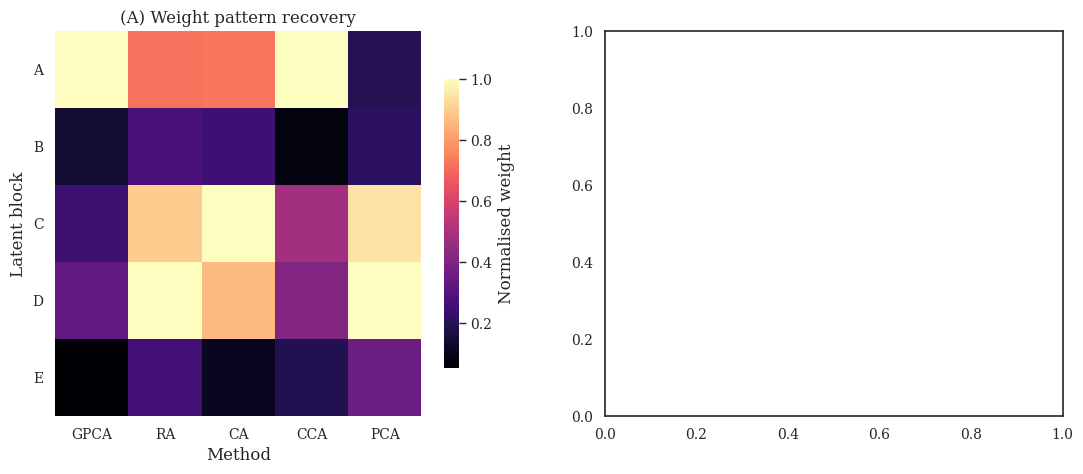

In [ ]:
# ── Logistic fit helper ───────────────────────────────────────────────────────
def logistic_func(x, L, k, x0, b):
    return L / (1 + np.exp(-k * (x - x0))) + b


# ── Prepare SNR / TPR data (from Exp 2 power results) ────────────────────────
# Build the per-run DataFrame used for the logistic-fit panel
df_snr = rejection_power_all.copy()
# Focus on a meaningful SNR window and exclude Spatial Average (too noisy)
# df_snr = df_snr[(df_snr["snr"] > 0) & (df_snr["snr"] <= 5)]
# df_snr = df_snr[df_snr["Method"] != "Spatial Average"]

# Reuse the raw boolean per-run rows for scatter (before aggregation)
# df_runs_power = all_power_resultspd.DataFrame([
#     r for r in all_power_results[0].itertuples(index=False)
#     # if 0 < r.snr <= 0.1 and r.Method != "Spatial Average"
# ]) if all_power_results else df_snr   # fallback to aggregated if runs not kept


# ── Build 2-panel publication figure ─────────────────────────────────────────
METHOD_COLORS = {
    "GPCA":           "#2c7bb6",
    "CCA":            "#d7191c",
    "Composites":     "#fdae61",
    "Regression":     "#abd9e9",
    "PCA":            "#12a15a",
    "Spatial Average":"#353210",
}

with mpl.rc_context(PUB_RC):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── Panel A : weight heatmap ──────────────────────────────────────────
    ax_A = axes[0]
    sns.heatmap(
        df_weights, ax=ax_A, cmap="magma",
        cbar_kws={"shrink": 0.75, "label": "Normalised weight"},
        linewidths=0.0, yticklabels=False,
    )
    block_size = len(df_weights) / 5
    ax_A.set_yticks([block_size * (i + 0.5) for i in range(5)])
    ax_A.set_yticklabels(["A", "B", "C", "D", "E"], rotation=0, fontsize=10)
    ax_A.set_xlabel("Method")
    ax_A.set_ylabel("Latent block")
    ax_A.set_title("(A) Weight pattern recovery")

    # ── Panel B : TPR vs SNR with logistic fits ───────────────────────────
    ax_B = axes[1]

    for method in df_snr["Method"].unique():
        m_data = df_snr[df_snr["Method"] == method].sort_values("snr")
        x = m_data["snr"].values
        y = m_data["rejection_rate"].values
        color = METHOD_COLORS.get(method, "gray")

        try:
            p0   = [max(y), 1.0, float(np.median(x)), float(min(y))]
            popt, _ = curve_fit(logistic_func, x, y, p0=p0, maxfev=5000)
            x_fit = np.linspace(x.min(), x.max(), 500)
            ax_B.scatter(x, y, color=color, alpha=0.35, s=25, edgecolors="none")
            ax_B.plot(x_fit, logistic_func(x_fit, *popt), color=color,
                      label=f"{method} ($x_0$={popt[2]:.2f})")
        except RuntimeError:
            # Fallback: plain scatter if curve_fit fails to converge
            ax_B.scatter(x, y, color=color, alpha=0.5, s=25, edgecolors="none",
                         label=method)

    ax_B.set_xlim(0, 0.1)
    ax_B.set_xlabel("Signal-to-Noise Ratio (SNR)")
    ax_B.set_ylabel("True Positive Rate")
    ax_B.set_title("(B) Power vs SNR")
    ax_B.legend(frameon=False, loc="lower right", fontsize=9)
    ax_B.spines[["top", "right"]].set_visible(False)
    ax_B.tick_params(direction="out", length=3)

    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/synthetic_experiments_publication.pdf",
                dpi=300, bbox_inches="tight")
    plt.savefig(f"{FIG_DIR}/synthetic_experiments_publication.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Final figure saved → {FIG_DIR}/synthetic_experiments_publication.pdf")